In [1]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

df1 = pd.read_csv('dataset_sintetico_FIRE_UdeA.csv')
df2 = pd.read_csv('dataset_sintetico_FIRE_UdeA_realista.csv')
metrics = pd.read_csv('reporte_metricas_FIRE_UdeA_realista.csv')
scores = pd.read_csv('scores_test_FIRE_UdeA_realista.csv')

# Eliminar participacion_ley30 de ambos datasets
df1 = df1.drop(columns=['participacion_ley30'], errors='ignore')
df2 = df2.drop(columns=['participacion_ley30'], errors='ignore')

print("df1 shape:", df1.shape)
print("df2 shape:", df2.shape)

df1 shape: (500, 7)
df2 shape: (80, 15)


In [51]:
print("=== DATASET SINTÉTICO (simple) ===")
print(f"Shape: {df1.shape}")
print(f"Columnas: {list(df1.columns)}")
print(f"\nLabel dist:\n{df1['label'].value_counts()}")
print(f"\nNulos:\n{df1.isnull().sum()}")
print(f"\nDescribe:\n{df1.describe().round(3)}")

print("\n=== DATASET SINTÉTICO REALISTA ===")
print(f"Shape: {df2.shape}")
print(f"Columnas: {list(df2.columns)}")
print(f"\nLabel dist:\n{df2['label'].value_counts()}")
print(f"\nNulos:\n{df2.isnull().sum()}")
print(f"\nDescribe:\n{df2.describe().round(3)}")

print("\n=== MÉTRICAS BASELINE ===")
print(metrics.to_string())

print("\n=== SCORES TEST ===")
print(scores.to_string())

=== DATASET SINTÉTICO (simple) ===
Shape: (500, 7)
Columnas: ['liquidez', 'dias_efectivo', 'cfo', 'hhi_fuentes', 'gastos_personal', 'tendencia_ingresos', 'label']

Label dist:
label
1    277
0    223
Name: count, dtype: int64

Nulos:
liquidez              0
dias_efectivo         0
cfo                   0
hhi_fuentes           0
gastos_personal       0
tendencia_ingresos    0
label                 0
dtype: int64

Describe:
       liquidez  dias_efectivo           cfo  hhi_fuentes  gastos_personal  \
count   500.000        500.000  5.000000e+02      500.000     5.000000e+02   
mean      1.646         89.341  2.336936e+06        0.497     5.502589e+07   
std       0.806         49.961  1.967952e+07        0.230     2.626534e+07   
min       0.314          5.811 -5.792511e+07        0.100     1.000105e+07   
25%       0.951         45.092 -1.110538e+07        0.321     3.315782e+07   
50%       1.686         87.569  2.536809e+06        0.495     5.496836e+07   
75%       2.342        132.1

In [52]:
print("\n=== DATASET SINTÉTICO REALISTA ===")
print(f"Shape: {df2.shape}")
print(f"Columnas: {list(df2.columns)}")
print(f"\nLabel dist:\n{df2['label'].value_counts()}")
print(f"\nNulos:\n{df2.isnull().sum()}")
print(f"\nDescribe:\n{df2.describe().round(3)}")


=== DATASET SINTÉTICO REALISTA ===
Shape: (80, 15)
Columnas: ['anio', 'unidad', 'ingresos_totales', 'gastos_personal', 'liquidez', 'dias_efectivo', 'cfo', 'participacion_regalias', 'participacion_servicios', 'participacion_matriculas', 'hhi_fuentes', 'endeudamiento', 'tendencia_ingresos', 'gp_ratio', 'label']

Label dist:
label
0    42
1    38
Name: count, dtype: int64

Nulos:
anio                        0
unidad                      0
ingresos_totales            0
gastos_personal             0
liquidez                    2
dias_efectivo               1
cfo                         5
participacion_regalias      0
participacion_servicios     0
participacion_matriculas    0
hhi_fuentes                 1
endeudamiento               8
tendencia_ingresos          3
gp_ratio                    0
label                       0
dtype: int64

Describe:
          anio  ingresos_totales  gastos_personal  liquidez  dias_efectivo  \
count    80.00      8.000000e+01     8.000000e+01    78.000        

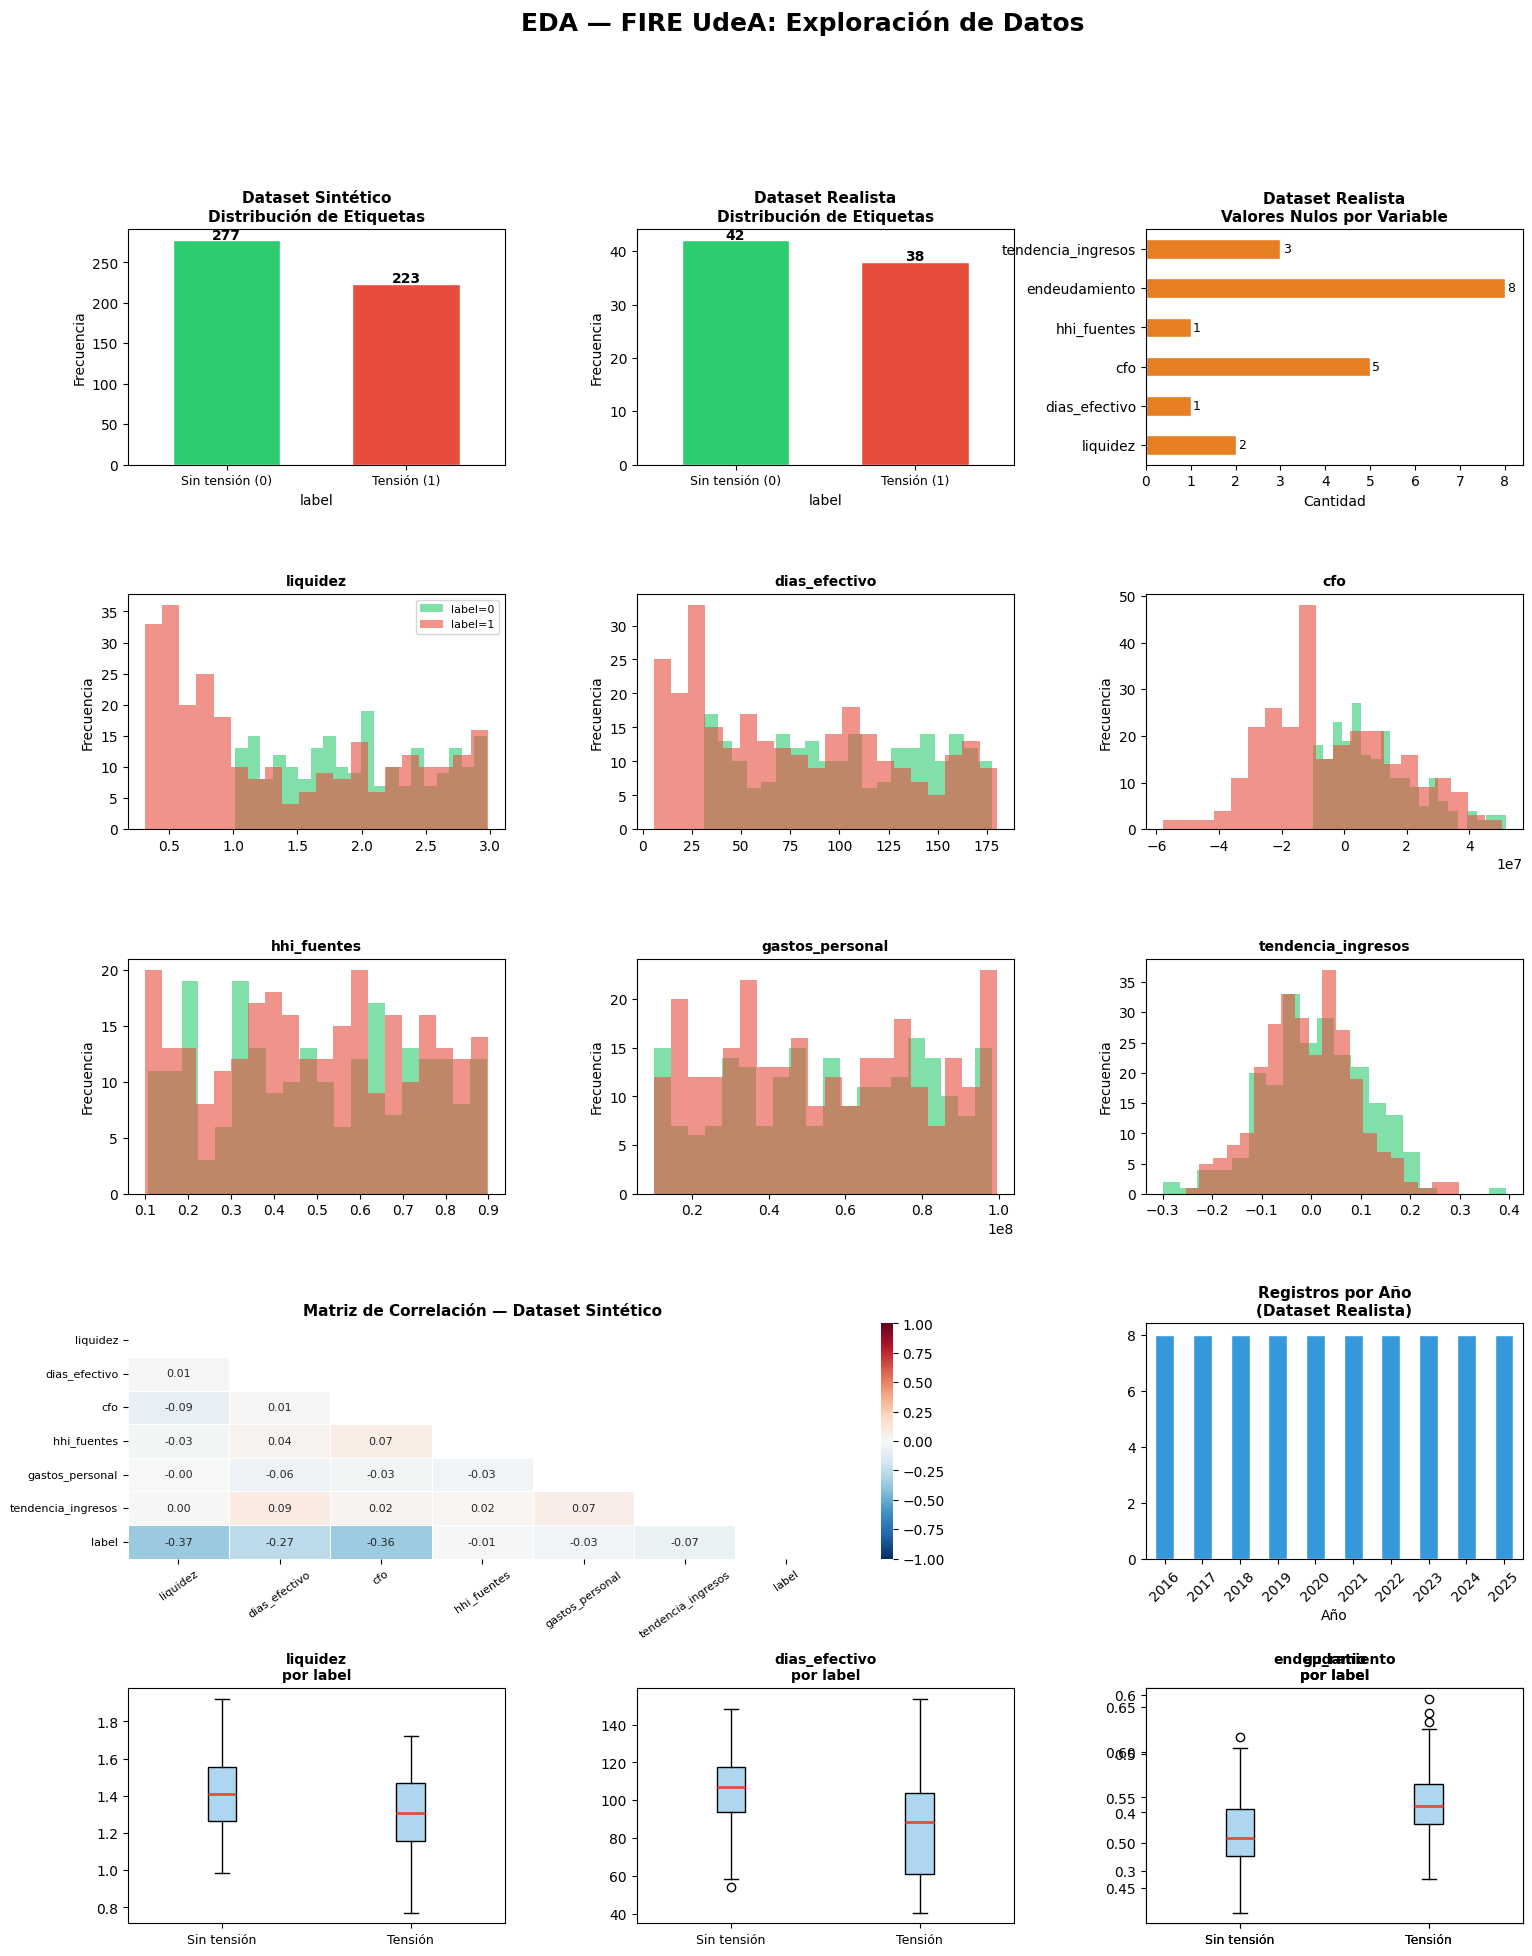

In [53]:
colors = ['#2ECC71', '#E74C3C']

fig = plt.figure(figsize=(18, 22))
fig.suptitle('EDA — FIRE UdeA: Exploración de Datos', fontsize=18, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(5, 3, figure=fig, hspace=0.55, wspace=0.35)

# 1.1 Label dist df1
ax = fig.add_subplot(gs[0, 0])
df1['label'].value_counts().plot(kind='bar', ax=ax, color=colors, edgecolor='white', width=0.6)
ax.set_title('Dataset Sintético\nDistribución de Etiquetas', fontsize=11, fontweight='bold')
ax.set_xticklabels(['Sin tensión (0)', 'Tensión (1)'], rotation=0, fontsize=9)
ax.set_ylabel('Frecuencia')
for bar in ax.patches:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, int(bar.get_height()),
            ha='center', fontsize=10, fontweight='bold')

# 1.2 Label dist df2
ax = fig.add_subplot(gs[0, 1])
df2['label'].value_counts().plot(kind='bar', ax=ax, color=colors, edgecolor='white', width=0.6)
ax.set_title('Dataset Realista\nDistribución de Etiquetas', fontsize=11, fontweight='bold')
ax.set_xticklabels(['Sin tensión (0)', 'Tensión (1)'], rotation=0, fontsize=9)
ax.set_ylabel('Frecuencia')
for bar in ax.patches:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, int(bar.get_height()),
            ha='center', fontsize=10, fontweight='bold')

# 1.3 Nulos df2
ax = fig.add_subplot(gs[0, 2])
nulls = df2.isnull().sum()
nulls = nulls[nulls > 0]
nulls.plot(kind='barh', ax=ax, color='#E67E22', edgecolor='white')
ax.set_title('Dataset Realista\nValores Nulos por Variable', fontsize=11, fontweight='bold')
ax.set_xlabel('Cantidad')
for i, v in enumerate(nulls.values):
    ax.text(v + 0.05, i, str(v), va='center', fontsize=9)

# 2. Distribuciones por label - df1
shared_feats = ['liquidez', 'dias_efectivo', 'cfo', 'hhi_fuentes', 'gastos_personal', 'tendencia_ingresos']
for i, feat in enumerate(shared_feats):
    row = 1 + i // 3
    col = i % 3
    ax = fig.add_subplot(gs[row, col])
    for label, color in zip([0, 1], colors):
        subset = df1[df1['label'] == label][feat].dropna()
        ax.hist(subset, bins=20, alpha=0.6, color=color, edgecolor='none', label=f'label={label}')
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_ylabel('Frecuencia')
    if i == 0:
        ax.legend(fontsize=8)

# 3. Correlación df1
ax = fig.add_subplot(gs[3, :2])
corr1 = df1.corr()
mask = np.triu(np.ones_like(corr1, dtype=bool))
sns.heatmap(corr1, mask=mask, ax=ax, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Matriz de Correlación — Dataset Sintético', fontsize=11, fontweight='bold')
ax.tick_params(axis='x', rotation=35, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)

# 4. Registros por año df2
ax = fig.add_subplot(gs[3, 2])
df2['anio'].value_counts().sort_index().plot(kind='bar', ax=ax, color='#3498DB', edgecolor='white')
ax.set_title('Registros por Año\n(Dataset Realista)', fontsize=11, fontweight='bold')
ax.set_xlabel('Año')
ax.tick_params(axis='x', rotation=45)

# 5. Boxplots por label - df2
num_feats_df2 = ['liquidez', 'dias_efectivo', 'gp_ratio', 'endeudamiento']
for i, feat in enumerate(num_feats_df2):
    col_idx = i if i < 3 else 2
    ax = fig.add_subplot(gs[4, col_idx])
    data_0 = df2[df2['label']==0][feat].dropna()
    data_1 = df2[df2['label']==1][feat].dropna()
    ax.boxplot([data_0, data_1], patch_artist=True,
               boxprops=dict(facecolor='#AED6F1'),
               medianprops=dict(color='#E74C3C', linewidth=2))
    ax.set_xticklabels(['Sin tensión', 'Tensión'], fontsize=9)
    ax.set_title(f'{feat}\npor label', fontsize=10, fontweight='bold')

plt.show()

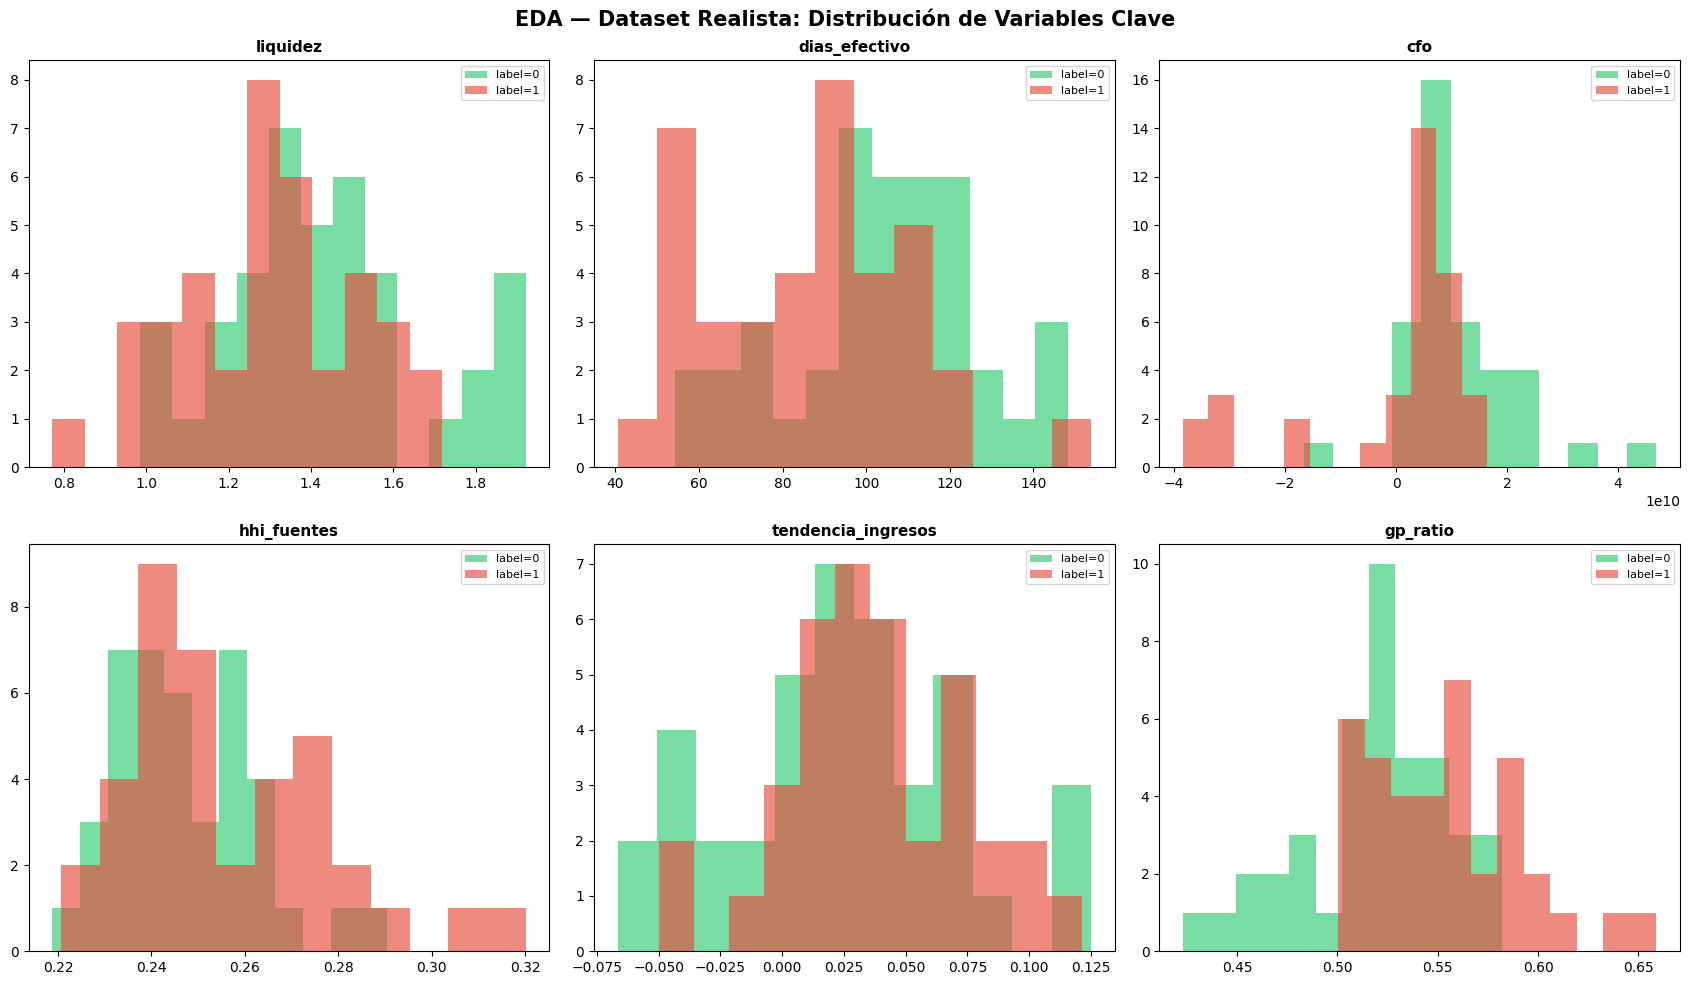

In [41]:
fig2, axes = plt.subplots(2, 3, figsize=(17, 10))
fig2.suptitle('EDA — Dataset Realista: Distribución de Variables Clave', fontsize=15, fontweight='bold')

feats_realista = ['liquidez', 'dias_efectivo', 'cfo', 'hhi_fuentes', 'tendencia_ingresos', 'gp_ratio']
for ax, feat in zip(axes.flatten(), feats_realista):
    for label, color in zip([0, 1], colors):
        subset = df2[df2['label'] == label][feat].dropna()
        ax.hist(subset, bins=12, alpha=0.65, color=color, edgecolor='none', label=f'label={label}')
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

fig2.tight_layout()
plt.show()

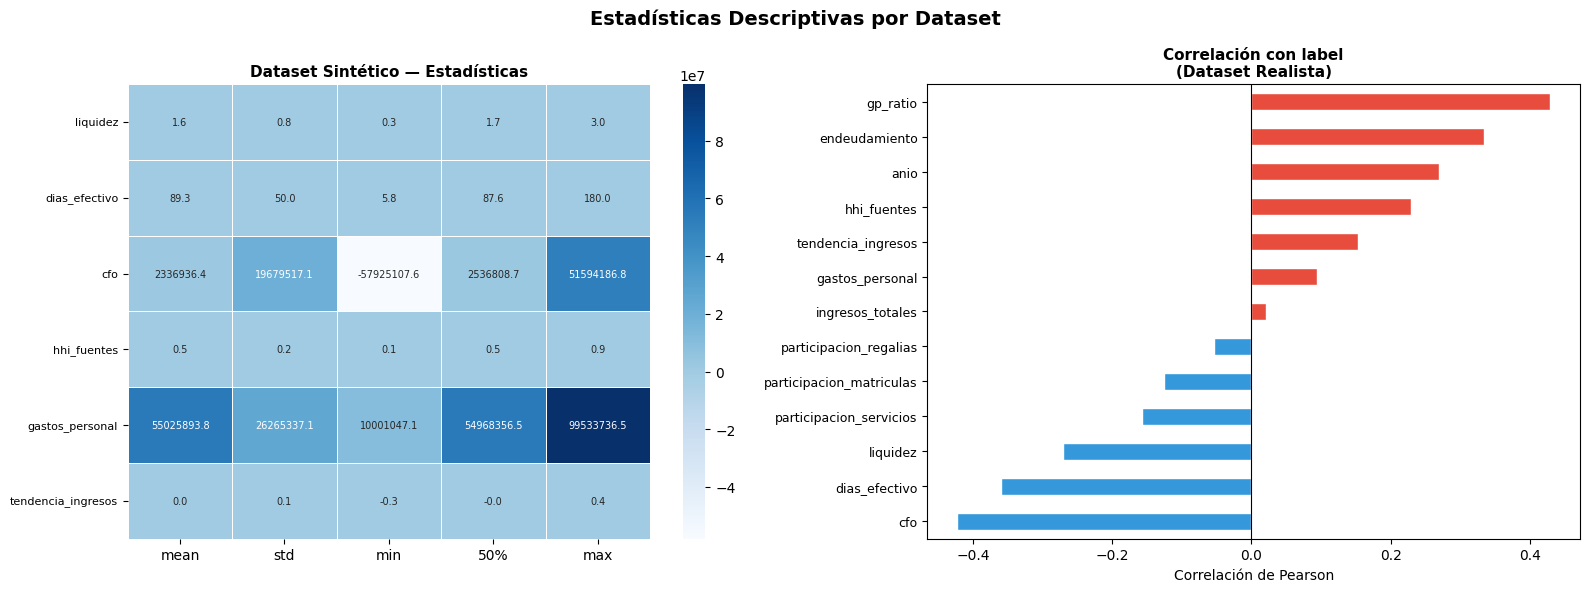

In [42]:
fig3, axes = plt.subplots(1, 2, figsize=(16, 6))
fig3.suptitle('Estadísticas Descriptivas por Dataset', fontsize=14, fontweight='bold')

# Heatmap estadísticas df1
desc1 = df1.drop('label', axis=1).describe().T[['mean','std','min','50%','max']]
sns.heatmap(desc1, ax=axes[0], cmap='Blues', annot=True, fmt='.1f',
            annot_kws={'size': 7}, linewidths=0.5)
axes[0].set_title('Dataset Sintético — Estadísticas', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

# Correlación con label - df2
corr_label = df2.select_dtypes(include='number').corr()['label'].drop('label').sort_values()
bar_colors = ['#E74C3C' if v > 0 else '#3498DB' for v in corr_label.values]
corr_label.plot(kind='barh', ax=axes[1], color=bar_colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlación con label\n(Dataset Realista)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Correlación de Pearson')
axes[1].tick_params(axis='y', labelsize=9)

fig3.tight_layout()
plt.show()

In [43]:
print("=== Correlación con label (Dataset Realista) ===")
corr = df2.select_dtypes(include='number').corr()['label'].drop('label').sort_values()
print(corr.round(3).to_string())

print("\n=== Top features protectoras (negativas) ===")
print(corr[corr < 0].to_string())

print("\n=== Top features de riesgo (positivas) ===")
print(corr[corr > 0].to_string())

=== Correlación con label (Dataset Realista) ===
cfo                        -0.423
dias_efectivo              -0.360
liquidez                   -0.271
participacion_servicios    -0.158
participacion_matriculas   -0.125
participacion_regalias     -0.053
ingresos_totales            0.021
gastos_personal             0.094
tendencia_ingresos          0.153
hhi_fuentes                 0.229
anio                        0.270
endeudamiento               0.335
gp_ratio                    0.429

=== Top features protectoras (negativas) ===
cfo                        -0.422841
dias_efectivo              -0.360356
liquidez                   -0.271244
participacion_servicios    -0.157805
participacion_matriculas   -0.125478
participacion_regalias     -0.053125

=== Top features de riesgo (positivas) ===
ingresos_totales      0.020774
gastos_personal       0.094200
tendencia_ingresos    0.152861
hhi_fuentes           0.228867
anio                  0.270158
endeudamiento         0.334509
gp_ratio   

In [58]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 2.6 MB/s eta 0:00:03
   ------ --------------------------------- 1.3/8.1 MB 3.3 MB/s eta 0:00:03
   ---------- ----------------------------- 2.1/8.1 MB 3.4 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.1 MB 3.6 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.1 MB 3.8 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.1 MB 3.9 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.1 MB 3.9 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.1 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 4.4 MB/s  0:00:01
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   - -------------------------------------- 1.0/37.3 MB 6.4 MB/s eta 0:00:06
   -- ------------------------------------- 2.4/37.3 MB 6.6 MB/s eta 0:00:06
   ---- ------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import RobustScaler, LabelEncoder

# Separar features numéricas (excluir columnas no numéricas y target)
cols_excluir = ['anio', 'unidad', 'label']
num_cols_df2 = [c for c in df2.select_dtypes(include='number').columns if c not in cols_excluir]

print("Columnas numéricas a imputar:", num_cols_df2)
print("\nNulos antes:\n", df2[num_cols_df2].isnull().sum()[df2[num_cols_df2].isnull().sum() > 0])

# KNN Imputer (mejor que media para datos financieros con estructura)
knn_imputer = KNNImputer(n_neighbors=5)
df2_imputed = df2.copy()
df2_imputed[num_cols_df2] = knn_imputer.fit_transform(df2[num_cols_df2])

print("\nNulos después:\n", df2_imputed[num_cols_df2].isnull().sum().sum(), "nulos restantes")
print("\nValores imputados por columna:")
for col in num_cols_df2:
    n_imp = df2[col].isnull().sum()
    if n_imp > 0:
        print(f"  {col}: {n_imp} valores imputados | "
              f"media original={df2[col].mean():.4f} | "
              f"media imputada={df2_imputed[col].mean():.4f}")

ModuleNotFoundError: No module named 'sklearn'